In [40]:
library(readxl)
library(ggfortify)
library(edgeR)
library(car)

In [41]:
became = data.frame(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés_161lipidesCommuns.xlsx',sheet=1))
miracle = data.frame(read_xlsx('../data/MIRACLE_LipidomicData_161LipidesCommuns.xlsx',sheet=1))

became_meta = data.frame(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés_161lipidesCommuns.xlsx',sheet=2))
miracle_meta = data.frame(read_xlsx('../data/MIRACLE_LipidomicData_161LipidesCommuns.xlsx',sheet=2))

New names:
• `ID-LCMS` -> `ID-LCMS...1`
• `ID-LCMS` -> `ID-LCMS...16`


In [42]:
became_num = became[,-c(1:7)]
miracle_num = miracle[,-c(1:7)]


became_tmp = became_meta[,c(1:3)]
miracle_tmp = miracle_meta[,c(1:3)]
colnames(became_tmp) = c('id','group','cluster')
colnames(miracle_tmp) = c('id','group','cluster')

became_tmp$cluster = paste0('B',became_tmp$cluster)
miracle_tmp$cluster = paste0('M',miracle_tmp$cluster)

became_tmp$cohort = 'BECAME'
miracle_tmp$cohort = 'MIRACLE'

meta = rbind(became_tmp,miracle_tmp)
rownames(meta) = paste0('X',meta$id)

In [43]:
dim(miracle)
dim(became)

[1] 161 184

[1] 161 202

In [36]:
rownames(became_tmp) = paste0('X',became_tmp[,1])

In [37]:
became_num = data.frame(t(became_num))
for(i in 1:ncol(became_num)){became_num[,i]=as.numeric(became_num[,i])}
became_num$response_var = as.factor(as.numeric(became_tmp[rownames(became_num),'cluster']=='B1'))

# Check for multicollinearity using VIF
vif_values <- vif(glm(response_var ~ ., data = became_num, family = "binomial"))

# Display VIF values
print(vif_values)

Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


        X1         X2         X3         X4         X5         X6         X7 
  723.5472   159.2525  1657.7987  2865.0270   279.4060   656.7819  1267.8671 
        X8         X9        X10        X11        X12        X13        X14 
  413.5119   391.5562   337.1713  3206.7564  6253.5839   370.4480  2529.5780 
       X15        X16        X17        X18        X19        X20        X21 
 6852.4963   283.0808  1858.9396   251.2078  1950.8697   708.0750   347.3734 
       X22        X23        X24        X25        X26        X27        X28 
  472.1495  3978.6031  7489.5730  3935.1912  6243.8510   902.8522  2226.0552 
       X29        X30        X31        X32        X33        X34        X35 
 7707.2042  3177.9896  1373.7471   556.8127  1044.5620   433.3237  1370.5813 
       X36        X37        X38        X39        X40        X41        X42 
 1531.8204   729.4363  1452.9994  1386.8518  1843.3817  3141.2400  1472.0911 
       X43        X44        X45        X46        X47        X4

In [39]:
for(i in 1:ncol(miracle_num)){miracle_num[,i]=as.numeric(miracle_num[,i])}
pca = prcomp(scale(log(t(miracle_num))))
print(dim(pca$x))
meta$cluster[meta$cluster=='MNA']='M-CTL'
p1 = autoplot(pca,data=meta[colnames(miracle_num),],col='cluster')+theme_bw()+scale_color_manual(values=c('grey90','darkolivegreen3','deepskyblue','mediumorchid'))

for(i in 1:ncol(became_num)){became_num[,i]=as.numeric(became_num[,i])}
pca = prcomp(scale(log(t(became_num))))
print(dim(pca$x))
meta$cluster[meta$cluster=='BCtrl']='B-CTL'
p2 = autoplot(pca,meta[colnames(became_num),],col='cluster')+scale_color_manual(values=c('grey90','darkolivegreen3','deepskyblue','mediumorchid'))+theme_bw()


options(repr.plot.width = 12, repr.plot.height = 5)

cowplot::plot_grid(p1+ggtitle('MIRACLE'),p2+ggtitle('BECAME'),ncol=2)

[1] 177 161


ERROR: Error in svd(x, nu = 0, nv = k): infinite or missing values in 'x'


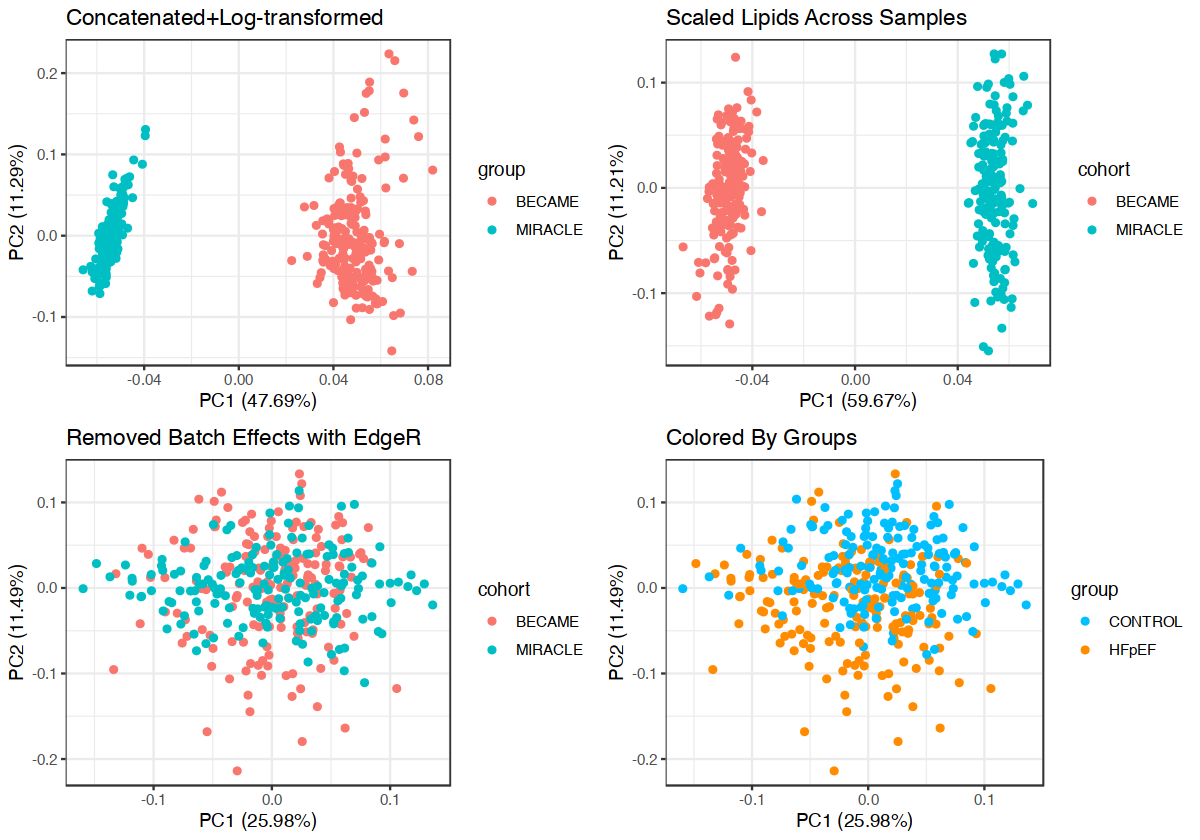

In [15]:
merged = data.frame(t(cbind(became_num,miracle_num)))
merged$group = 'BECAME'
merged[rownames(merged)[rownames(merged)%in%colnames(miracle)],'group'] = 'MIRACLE'
p1 = autoplot(prcomp(scale(merged[,-ncol(merged)])),data=merged,col='group')+theme_bw()

# log-transform
merge_scaled = log(merged[,-ncol(merged)])
# remove batch reffect
m = limma::removeBatchEffect(t(merge_scaled),batch = merged$group)

# Scale Data
meta$group[meta$group=='Ctrl'] = 'CONTROL'
meta$group[meta$group=='FEP'] = 'HFpEF'
scaled_df = data.frame(scale(t(m)))
rows = rownames(meta)[rownames(meta) %in% rownames(scaled_df)]

p2 = autoplot(prcomp(scale(merge_scaled[,-ncol(merge_scaled)])),data=merged[rownames(merge_scaled),],col='group')+theme_bw()+labs(col='cohort')
p3 = autoplot(prcomp(scaled_df[rows,]),data=meta[rows,],col='cohort')+theme_bw()
p4 = autoplot(prcomp(scaled_df[rows,]),data=meta[rows,],col='group')+theme_bw()+scale_color_manual(values=c('deepskyblue','darkorange'))


options(repr.plot.width = 10, repr.plot.height = 7)

cowplot::plot_grid(p1+ggtitle('Concatenated+Log-transformed'),
                   p2+ggtitle('Scaled Lipids Across Samples'),
                   p3+ggtitle('Removed Batch Effects with EdgeR'),
                   p4+ggtitle('Colored By Groups'),ncol=2)

In [22]:
pca_pre = data.frame(prcomp(scale(merge_scaled[,-ncol(merge_scaled)]))$x)
pca = data.frame(prcomp(scaled_df[rows,])$x)
pca_toplot = cbind(pca_pre[rows,c('PC1','PC2')],pca[rows,c('PC1','PC2')],meta[rows,'cohort'])

In [24]:
colnames(pca_toplot) = c('PC1.pre','PC2.pre','PC1.post','PC2.post','cohort')

In [16]:
pca$cohort = meta[rows,'cohort']

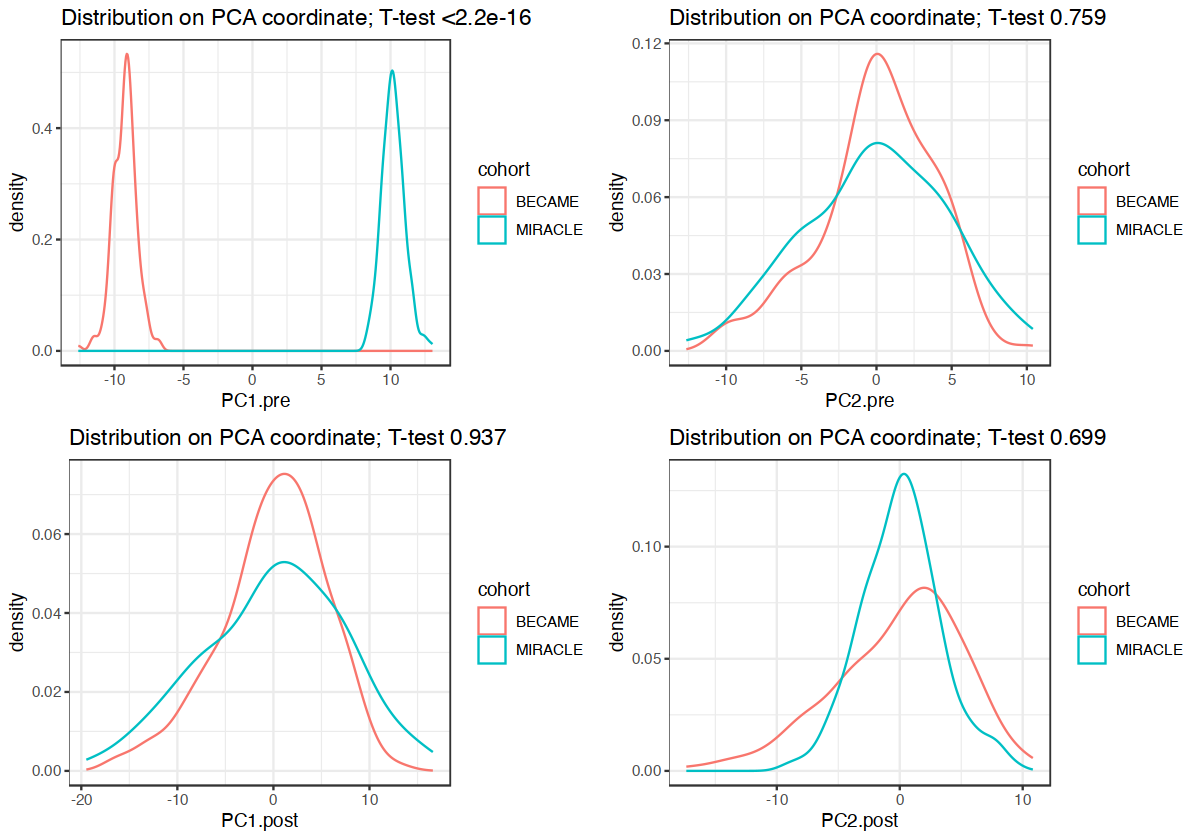

In [32]:
p1 = ggplot(pca_toplot,aes(PC1.pre,col=cohort))+geom_density()+theme_bw()+ggtitle(paste0('Distribution on PCA coordinate; T-test <2.2e-16'))
p2 = ggplot(pca_toplot,aes(PC2.pre,col=cohort))+geom_density()+theme_bw()+ggtitle(paste0('Distribution on PCA coordinate; T-test ',round(t.test(pca_toplot$PC2.pre~pca_toplot$cohort)$p.value,digits=3)))

p3 = ggplot(pca_toplot,aes(PC1.post,col=cohort))+geom_density()+theme_bw()+ggtitle(paste0('Distribution on PCA coordinate; T-test ',round(t.test(pca_toplot$PC1.post~pca_toplot$cohort)$p.value,digits=3)))
p4 = ggplot(pca_toplot,aes(PC2.post,col=cohort))+geom_density()+theme_bw()+ggtitle(paste0('Distribution on PCA coordinate; T-test ',round(t.test(pca_toplot$PC2.post~pca_toplot$cohort)$p.value,digits=3)))

cowplot::plot_grid(p1,p2,p3,p4,ncol=2)

In [27]:
t.test(pca_toplot$PC1.post~pca_toplot$cohort)


	Welch Two Sample t-test

data:  pca_toplot$PC1.post by pca_toplot$cohort
t = -0.078838, df = 325.43, p-value = 0.9372
alternative hypothesis: true difference in means between group BECAME and group MIRACLE is not equal to 0
95 percent confidence interval:
 -1.418403  1.309100
sample estimates:
 mean in group BECAME mean in group MIRACLE 
          -0.02748106            0.02717054 


In [6]:
write.table(scaled_df[rows,],'data/merged_dataset.csv',quote=F,sep=',')
write.table(meta[rows,],'data/merged_dataset_meta.csv',quote=F,sep=',')